<a href="https://colab.research.google.com/github/TranMinhHuy15/cinematicket-booking-database/blob/main/VISUALPLANE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving FINAL_DATA_FOR_TRAINING.parquet to FINAL_DATA_FOR_TRAINING.parquet
User uploaded file "FINAL_DATA_FOR_TRAINING.parquet" with length 207338871 bytes


In [2]:
import pandas as pd

# Assuming the uploaded file is named 'FINAL_DATA_FOR_TRAINING.parquet'
# You can change the filename if it's different
file_name = 'FINAL_DATA_FOR_TRAINING.parquet'
df = pd.read_parquet(file_name)

# Display the first 5 rows to verify the data is loaded correctly
display(df.head(20))

,Year,Quarter,Origin,Dest,OriginState,DestState,COVID_Period,Cabin_Class,total_passengers,weighted_avg_fare,...,Dom_Cost,Dom_PerGal,Int_Cons,Int_Cost,Int_PerGal,Total_Cons,Total_Cost,Total_PerGal,Origin_Disaster_Count,Dest_Disaster_Count
0,2008,4,EYW,STX,FL,VI,0,Economy,1.0,511.060000,...,2431.766667,2.556667,427.433333,1211.900000,2.823333,1378.233333,3643.633333,2.940000,6,3
1,2008,2,IAH,BTV,TX,VT,0,Economy,117.0,167.196838,...,3442.166667,3.186667,477.800000,1599.533333,3.465000,1558.533333,5041.733333,3.345000,8,0
2,2008,3,AVL,MFR,NC,OR,0,Economy,2.0,303.220000,...,3671.666667,3.473333,487.333333,1872.133333,3.695000,1540.600000,5543.833333,3.586667,0,1
3,2008,2,MOT,DLH,ND,MN,0,Economy,2.0,298.550000,...,3442.166667,3.186667,477.800000,1599.533333,3.465000,1558.533333,5041.733333,3.345000,0,6
4,2008,4,MEM,TRI,TN,TN,0,Premium,21.0,540.057143,...,2431.766667,2.556667,427.433333,1211.900000,2.823333,1378.233333,3643.633333,2.940000,0,0
5,2008,4,AGS,LAW,GA,OK,0,Economy,5.0,245.136000,...,2431.766667,2.556667,427.433333,1211.900000,2.823333,1378.233333,3643.633333,2.940000,0,11
6,2008,3,CLE,DEN,OH,CO,0,Premium,200.0,433.114350,...,3671.666667,3.473333,487.333333,1872.133333,3.695000,1540.600000,5543.833333,3.586667,0,0
7,2008,4,ERI,SAV,PA,GA,0,Economy,6.0,197.636667,...,2431.766667,2.556667,427.433333,1211.900000,2.823333,1378.233333,3643.633333,2.940000,0,0
8,2008,2,ATW,RSW,WI,FL,0,Business,2.0,584.665000,...,3442.166667,3.186667,477.800000,1599.533333,3.465000,1558.533333,5041.733333,3.345000,31,1
9,2008,4,MEM,SJC,TN,CA,0,Premium,17.0,417.698824,...,2431.766667,2.556667,427.433333,1211.900000,2.823333,1378.233333,3643.633333,2.940000,0,12


In [3]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

print("\nMissing values count per column:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0]) # Display only columns with missing values


Total rows: 8630243
Total columns: 26

Missing values count per column:


,0


In [4]:
print("Column Data Types:")
display(df.dtypes)

Column Data Types:


,0
Year,int64
Quarter,int64
Origin,object
Dest,object
OriginState,object
DestState,object
COVID_Period,int32
Cabin_Class,object
total_passengers,float64
weighted_avg_fare,float64


In [6]:
print("Unique years in the 'Year' column:")
display(df['Year'].unique())

Unique years in the 'Year' column:


array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [7]:
for column in df.columns:
    print(f"\n--- Column: {column} ---")
    unique_values_count = df[column].nunique()
    print(f"Number of unique values: {unique_values_count}")

    if unique_values_count < 50:  # Display unique values if there are less than 50 distinct ones
        print("Unique values and their counts:")
        display(df[column].value_counts().sort_index())
    else:
        print("Too many unique values to display all. Here are the top 10 most frequent values:")
        display(df[column].value_counts().head(10))


--- Column: Year ---
Number of unique values: 18
Unique values and their counts:


,count
Year,
2008,498118
2009,495929
2010,498822
2011,509809
2012,499389
2013,490976
2014,490356
2015,483839
2016,475417



--- Column: Quarter ---
Number of unique values: 4
Unique values and their counts:


,count
Quarter,
1,2147678
2,2219060
3,2153398
4,2110107



--- Column: Origin ---
Number of unique values: 561
Too many unique values to display all. Here are the top 10 most frequent values:


...

,count
Total_PerGal,
2.310000,507410
1.960000,248445
1.653333,231697
1.983333,135465
2.246667,134286
2.226667,133492
2.460000,132971
1.986667,131976
1.865000,131018



--- Column: Origin_Disaster_Count ---
Number of unique values: 154
Too many unique values to display all. Here are the top 10 most frequent values:


,count
Origin_Disaster_Count,
0,5229045
1,480793
2,239216
4,205535
3,198604
5,126183
9,117217
6,117047
7,109776



--- Column: Dest_Disaster_Count ---
Number of unique values: 154
Too many unique values to display all. Here are the top 10 most frequent values:


,count
Dest_Disaster_Count,
0,5226740
1,480337
2,239972
4,205376
3,198349
5,126129
6,117508
9,117163
7,109656


Phân tích xu hướng thời gian: Trực quan hóa các xu hướng của tổng số hành khách (total_passengers), giá vé trung bình (weighted_avg_fare), GDP, tỷ lệ thất nghiệp (UNRATE), và tổng chi phí (Total_Cost) theo năm (Year) và quý (Quarter). Đồng thời, xem xét tác động của cột COVID_Period lên các xu hướng này để hiểu sự thay đổi theo thời gian.
Phân tích phân bố địa lý: Xác định và trực quan hóa các bang xuất phát (OriginState) và bang đến (DestState) có lượng hành khách (total_passengers) và giá vé trung bình (weighted_avg_fare) cao nhất/thấp nhất. Có thể sử dụng biểu đồ cột hoặc bản đồ (nếu có dữ liệu địa lý).
Phân tích tác động của thiên tai: Trực quan hóa mối quan hệ giữa số lượng thiên tai tại điểm xuất phát (Origin_Disaster_Count), số lượng thiên tai tại điểm đến (Dest_Disaster_Count) và các yếu tố chuyến bay như total_passengers và weighted_avg_fare để đánh giá mức độ ảnh hưởng.
Phân tích mối quan hệ giữa các yếu tố kinh tế và chuyến bay: Trực quan hóa mối quan hệ hoặc sự tương quan giữa các chỉ số kinh tế như GDP, tỷ lệ thất nghiệp (UNRATE), chỉ số giá tiêu dùng (CPI) và các chỉ số liên quan đến chuyến bay như total_passengers và weighted_avg_fare.
Phân tích đặc điểm chuyến bay: Trực quan hóa phân bố của distance (khoảng cách) và mối quan hệ giữa distance với total_passengers và weighted_avg_fare để xem khoảng cách có ảnh hưởng như thế nào đến lượng hành khách và giá vé.
Final Task: Tóm tắt các phát hiện chính từ các biểu đồ trực quan hóa để đưa ra cái nhìn tổng quan về dữ liệu và chuẩn bị cho các bước tiền xử lý hoặc huấn luyện mô hình tiếp theo.

### 1. Phân tích phân bố của `total_passengers`

In [12]:
import pandas as pd

# Đảm bảo df_temp có sẵn, nếu không, tạo lại từ df
# (Trong môi trường Colab, df_temp đã tồn tại từ các bước trước)
# df_temp = df.copy()
# df_temp['total_passengers_int'] = df_temp['total_passengers'].astype(int)

print("\nBảng tần suất đầy đủ của Số Lượng Hành Khách:")
passenger_counts_full = df_temp['total_passengers_int'].value_counts().sort_index()
display(passenger_counts_full.to_frame(name='Tần Suất'))


Bảng tần suất đầy đủ của Số Lượng Hành Khách:


,Tần Suất
total_passengers_int,
1,2124152
2,1013557
3,628922
4,446574
5,342049
...,...
34318,1
34691,1
34733,1


In [16]:
# Tải lại bảng tần suất đầy đủ (nếu chưa có trong kernel hiện tại)
# passenger_counts_full = df['total_passengers'].value_counts().sort_index()

# Lọc các giá trị total_passengers thỏa mãn cả hai điều kiện:
# 1. Vượt quá ngưỡng passenger_threshold (ví dụ: 1000)
# 2. Có tần suất xuất hiện chỉ là 1

# Đảm bảo df_temp được khởi tạo và có cột total_passengers_int
if 'df_temp' not in locals() or 'total_passengers_int' not in df_temp.columns:
    df_temp = df.copy()
    df_temp['total_passengers_int'] = df_temp['total_passengers'].astype(int)

# Tạo bảng tần suất nếu chưa tồn tại
if 'passenger_counts_full' not in locals():
    passenger_counts_full = df_temp['total_passengers_int'].value_counts().sort_index()


anomalous_values = passenger_counts_full[
    (passenger_counts_full.index > passenger_threshold) & (passenger_counts_full == 1)
].index.tolist()

print(f"Các giá trị 'total_passengers' bất thường (vượt quá {passenger_threshold} và có tần suất 1):")
if anomalous_values:
    display(pd.Series(anomalous_values))
    print(f"Tổng số giá trị bất thường như vậy: {len(anomalous_values)}")
else:
    print("Không tìm thấy giá trị 'total_passengers' nào thỏa mãn cả hai điều kiện này.")

Các giá trị 'total_passengers' bất thường (vượt quá 1000 và có tần suất 1):


,0
0,5019
1,5037
2,5383
3,5545
4,5918
...,...
3579,34318
3580,34691
3581,34733
3582,34861


Tổng số giá trị bất thường như vậy: 3584


### 2. Phân tích phân bố của `weighted_avg_fare` theo thời gian

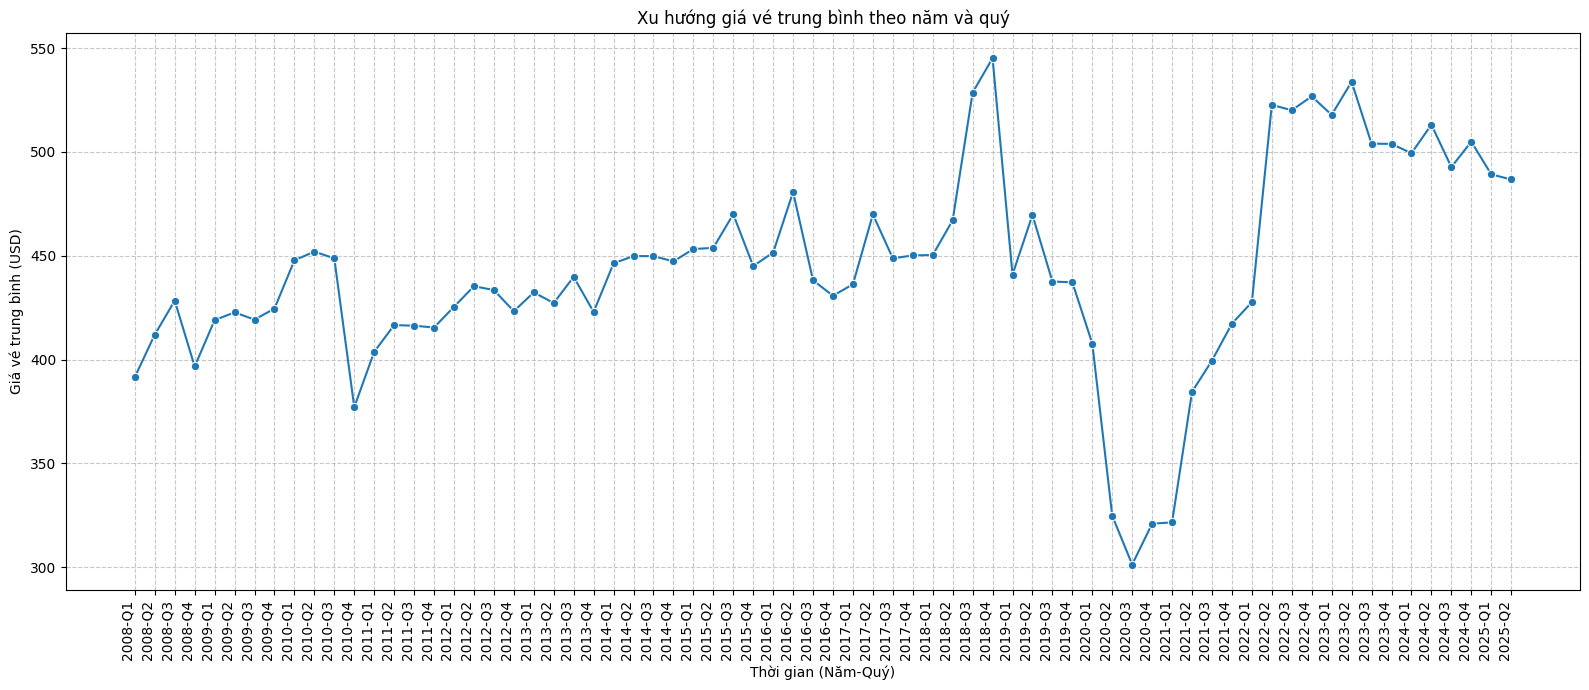

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Year and Quarter to get the average weighted_avg_fare
fare_time_series = df.groupby(['Year', 'Quarter'])['weighted_avg_fare'].mean().reset_index()

# Convert Quarter to a more readable format if needed (e.g., 'Q1', 'Q2', etc.)
fare_time_series['Quarter_Label'] = fare_time_series['Quarter'].apply(lambda x: f'Q{int(x)}')

# Combine Year and Quarter for a continuous time axis
fare_time_series['Time'] = fare_time_series['Year'].astype(str) + '-' + fare_time_series['Quarter_Label']

plt.figure(figsize=(16, 7))
sns.lineplot(x='Time', y='weighted_avg_fare', data=fare_time_series, marker='o')
plt.title('Xu hướng giá vé trung bình theo năm và quý')
plt.xlabel('Thời gian (Năm-Quý)')
plt.ylabel('Giá vé trung bình (USD)')
plt.xticks(rotation=90, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Tiếp theo, chúng ta sẽ xem xét ảnh hưởng của `COVID_Period` lên giá vé trung bình. Điều này có thể được thực hiện bằng cách so sánh giá vé trung bình trước, trong và sau thời kỳ COVID.

/tmp/ipykernel_7784/474302540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='COVID_Period', y='weighted_avg_fare', data=fare_by_covid_period, palette='viridis')


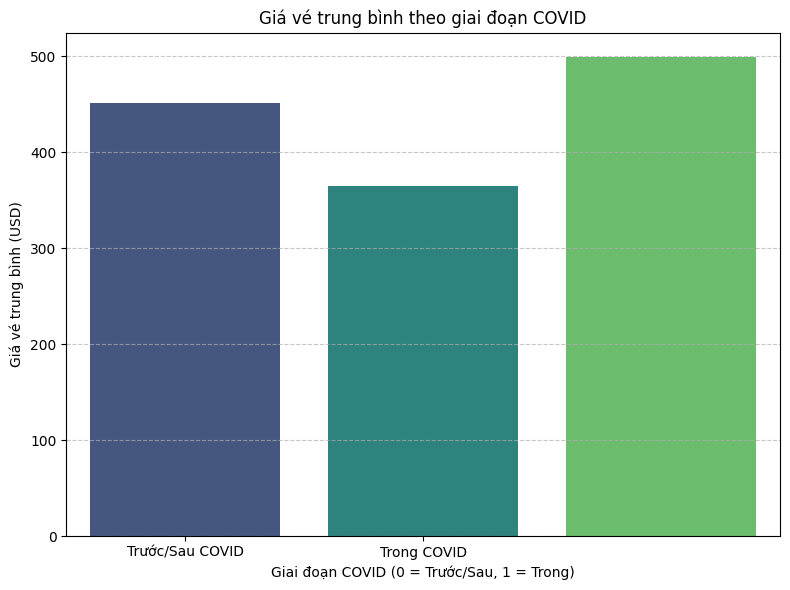

In [18]:
# Analyze weighted_avg_fare by COVID_Period
fare_by_covid_period = df.groupby('COVID_Period')['weighted_avg_fare'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='COVID_Period', y='weighted_avg_fare', data=fare_by_covid_period, palette='viridis')
plt.title('Giá vé trung bình theo giai đoạn COVID')
plt.xlabel('Giai đoạn COVID (0 = Trước/Sau, 1 = Trong)')
plt.ylabel('Giá vé trung bình (USD)')
plt.xticks([0, 1], ['Trước/Sau COVID', 'Trong COVID'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Bây giờ, chúng ta sẽ xem xét phân bố địa lý của `weighted_avg_fare` dựa trên `OriginState` và `DestState`.

/tmp/ipykernel_7784/269701006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='OriginState', y='weighted_avg_fare', data=top_origin_states_fare, palette='magma')


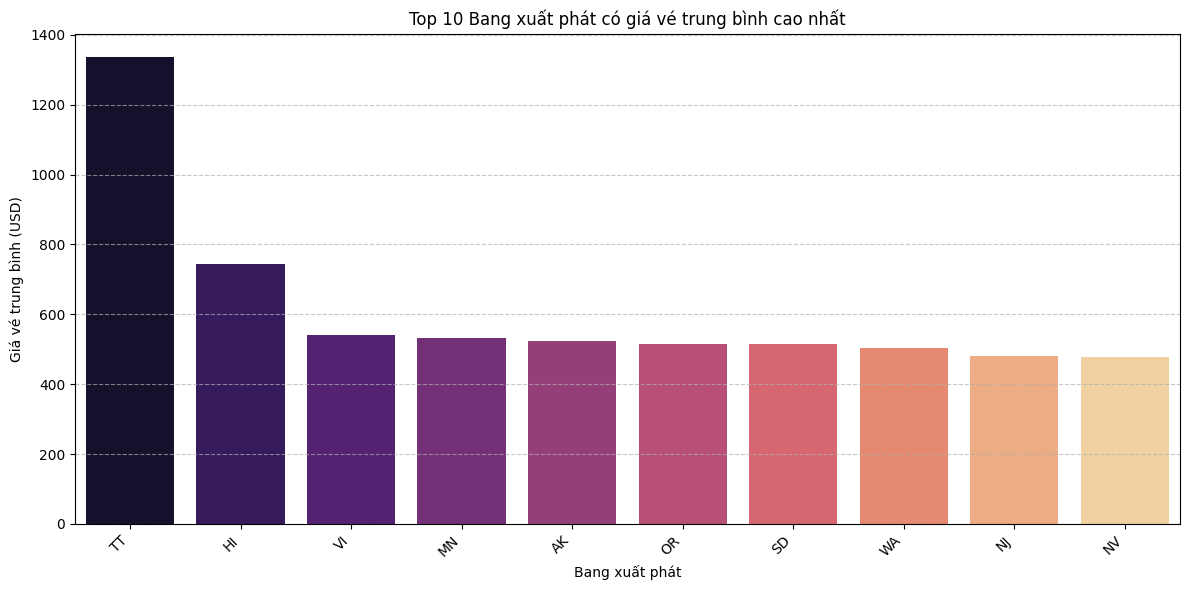

/tmp/ipykernel_7784/269701006.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DestState', y='weighted_avg_fare', data=top_dest_states_fare, palette='cividis')


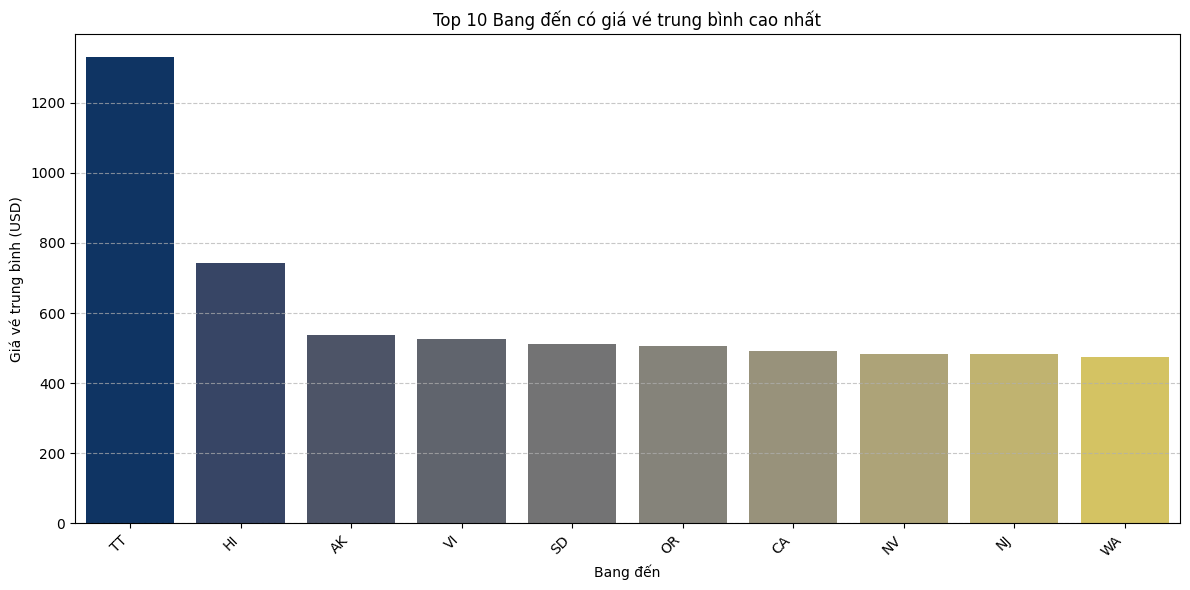

In [20]:
# Top 10 Origin States by weighted_avg_fare
top_origin_states_fare = df.groupby('OriginState')['weighted_avg_fare'].mean().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='OriginState', y='weighted_avg_fare', data=top_origin_states_fare, palette='magma')
plt.title('Top 10 Bang xuất phát có giá vé trung bình cao nhất')
plt.xlabel('Bang xuất phát')
plt.ylabel('Giá vé trung bình (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Top 10 Dest States by weighted_avg_fare
top_dest_states_fare = df.groupby('DestState')['weighted_avg_fare'].mean().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='DestState', y='weighted_avg_fare', data=top_dest_states_fare, palette='cividis')
plt.title('Top 10 Bang đến có giá vé trung bình cao nhất')
plt.xlabel('Bang đến')
plt.ylabel('Giá vé trung bình (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()